In [1]:
from pathlib import Path


def _repo_root_with_l2_run() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / "yolo11s_l2_export" / "runs" / "yolo11s_l2").is_dir():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(
        "Could not find yolo11s_l2_export/runs/yolo11s_l2; run the notebook from the repo root or Analysis/."
    )


BASE = str(_repo_root_with_l2_run() / "yolo11s_l2_export" / "runs" / "yolo11s_l2")

## **Part IV: Iterative Model Improvement**

### Improvement Justification

In Part III, training YOLOv11s on the same VisDrone dataset as the baseline produced a noticeably larger gap between training loss (1.1992) and validation loss (1.3172) compared to YOLOv11n (~0.118 vs ~0.025). 
This indicates that the larger model is overfitting. It has more parameters and therefore more capacity to memorize training data rather than generalizing to unseen images.

To address this, **weight decay (L2 regularization)** is applied. Weight decay adds a penalty to the loss function that discourages large parameter values, which forces the model to learn simpler and more generalizable features. 
This is a standard and well-established technique for reducing overfitting in deep learning.

### Controlled Modification

All settings were kept identical to Part III except for the weight decay value:

| Setting | Part III (YOLOv11s) | Part IV (YOLOv11s + L2) |
|---|---|---|
| Dataset | VisDrone2019 | VisDrone2019 |
| Model | YOLOv11s | YOLOv11s |
| Image Size | 640 | 640 |
| Batch Size | 16 | 16 |
| Max Epochs | 200 | 200 |
| Patience | 50 | 50 |
| **Weight Decay** | **0.0005 (default)** | **0.001** |

The only change from Part III is increasing weight decay from the Ultralytics default (0.0005) to 0.001.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

results_path = f"{BASE}/results.csv"

df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()

# final epoch metrics
final = df.iloc[-1]
print("=== Final Epoch Results ===")
print(f"mAP@50:        {final['metrics/mAP50(B)']:.4f}")
print(f"mAP@50-95:     {final['metrics/mAP50-95(B)']:.4f}")
print(f"Precision:     {final['metrics/precision(B)']:.4f}")
print(f"Recall:        {final['metrics/recall(B)']:.4f}")
print(f"Train Box Loss:{final['train/box_loss']:.4f}")
print(f"Val Box Loss:  {final['val/box_loss']:.4f}")

=== Final Epoch Results ===
mAP@50:        0.4122
mAP@50-95:     0.2450
Precision:     0.5304
Recall:        0.3978
Train Box Loss:1.2193
Val Box Loss:  1.2578


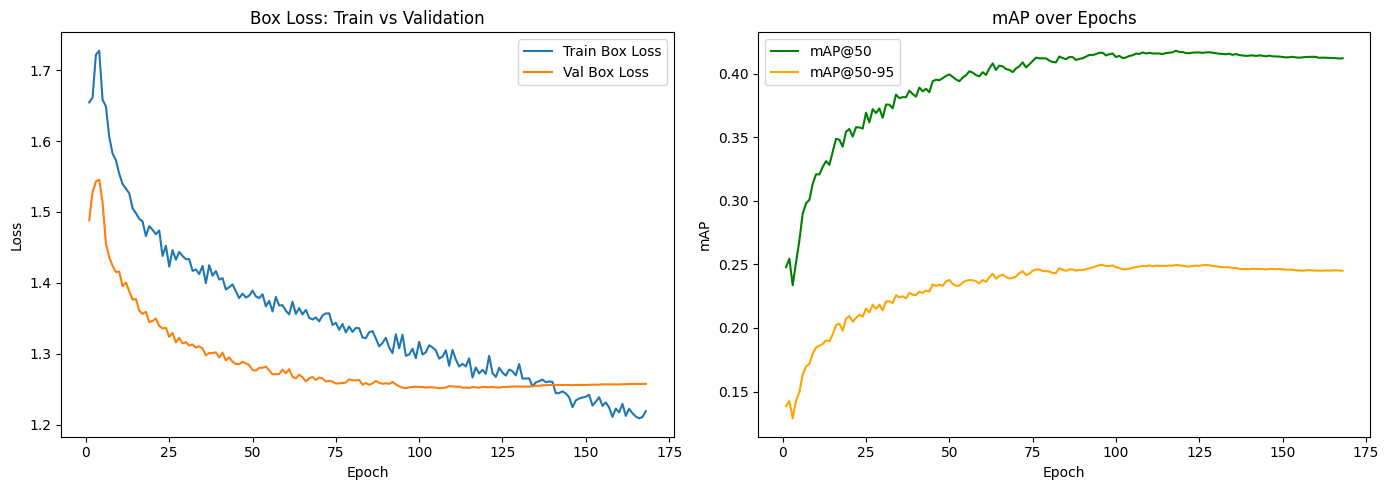

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
axes[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
axes[0].set_title('Box Loss: Train vs Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# mAP curve
axes[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='green')
axes[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='orange')
axes[1].set_title('mAP over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mAP')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{BASE}/loss_map_curves.png", dpi=150)
plt.show()

In [4]:
summary = {
    "Model": ["YOLOv11n"],
    "Epochs": [len(df)],
    "mAP@50": [round(final['metrics/mAP50(B)'], 4)],
    "mAP@50-95": [round(final['metrics/mAP50-95(B)'], 4)],
    "Precision": [round(final['metrics/precision(B)'], 4)],
    "Recall": [round(final['metrics/recall(B)'], 4)],
}
pd.DataFrame(summary)

,Model,Epochs,mAP@50,mAP@50-95,Precision,Recall
0,YOLOv11n,168,0.4122,0.245,0.5304,0.3978


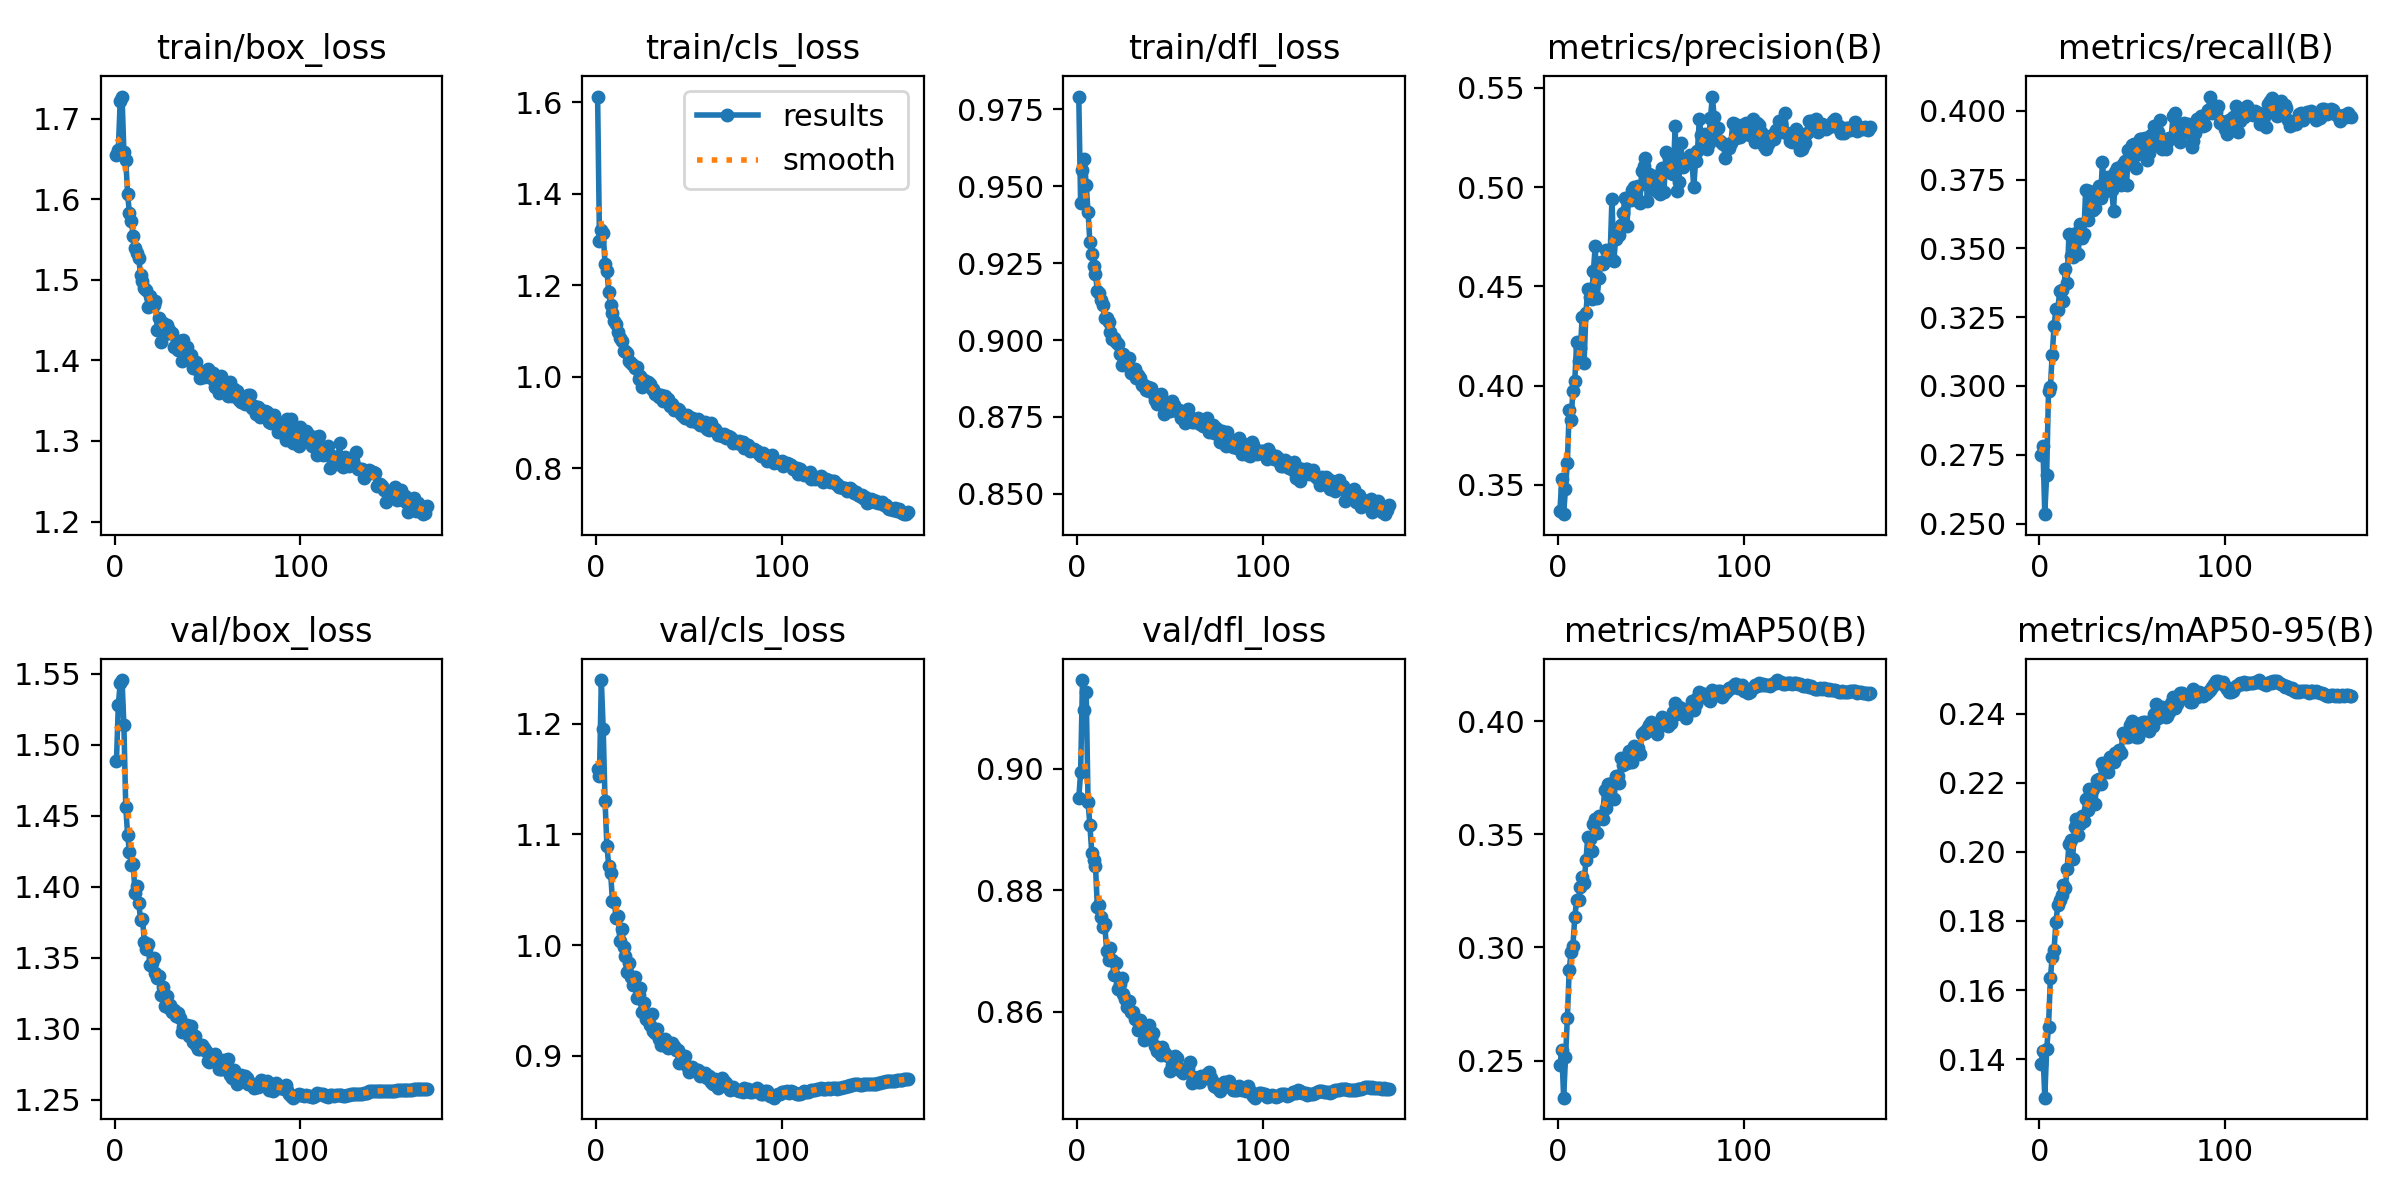

In [5]:
from IPython.display import Image, display
display(Image(f"{BASE}/results.png"))

### **Discussion**

**Note:** 200 epochs were set with a patience of 50 during training. Early stopping triggered at epoch 147, meaning no improvement was observed in the last 50 epochs. The best model was saved as best.pt.

### 1. Training vs. Validation Loss

The loss curves above plot the **box loss** for both the training set and the validation set across all 147 epochs. The key observations are:

- Both curves descend steadily from the start of training, indicating the model is learning meaningful object detection features.
- After approximately epoch 80–100, both curves begin to slow down, with only small decreases in loss through the remaining epochs.
- At the final epoch (epoch 147), the **training box loss is 1.1992** and the **validation box loss is 1.3172**, a gap of roughly **0.118**.

### 2. Convergence Behavior

The model has **converged**. Convergence is visible because:
- Neither the training nor the validation loss shows meaningful improvement in the later epochs.
- The mAP@50 stabilizes around **0.41** and mAP@50-95 around **0.245**, with no upward trend continuing toward the end of training.
- Both curves are smooth and consistent without sudden spikes, suggesting stable gradient updates and appropriate learning rate scheduling.

Early stopping with patience=50 was enabled, and training stopped at epoch 147, confirming the model had genuinely converged and additional epochs would not have improved performance.

### 3. Results Curves (results.png)

The results.png panel shows all training and validation losses alongside precision, recall, mAP@50, and mAP@50-95 across all epochs.

All three training losses (box, cls, dfl) decrease consistently throughout training without divergence, indicating stable optimization.
The validation losses mirror this behavior but increase slightly earlier, which is a normal and healthy pattern.

Precision is noticeably noisy throughout training, fluctuating across epochs.
This is common in YOLO training because precision is threshold-sensitive, meaning small shifts in the confidence threshold during validation can cause visible swings in the metric.
The smoothed trend shows precision stabilizing around **0.52–0.53**, consistent with the final reported value of 0.5294.

Recall shows a steadier upward trend, gradually improving across training and settling around **0.40**.
Both mAP curves rise in the first half of training and then increase, confirming convergence.
The gap between mAP@50 (0.4135) and mAP@50-95 (0.2456) reflects that the model finds objects in roughly the right location but still struggles with tight bounding box localization, though this gap is slightly smaller than what was observed in the YOLOv11n baseline.

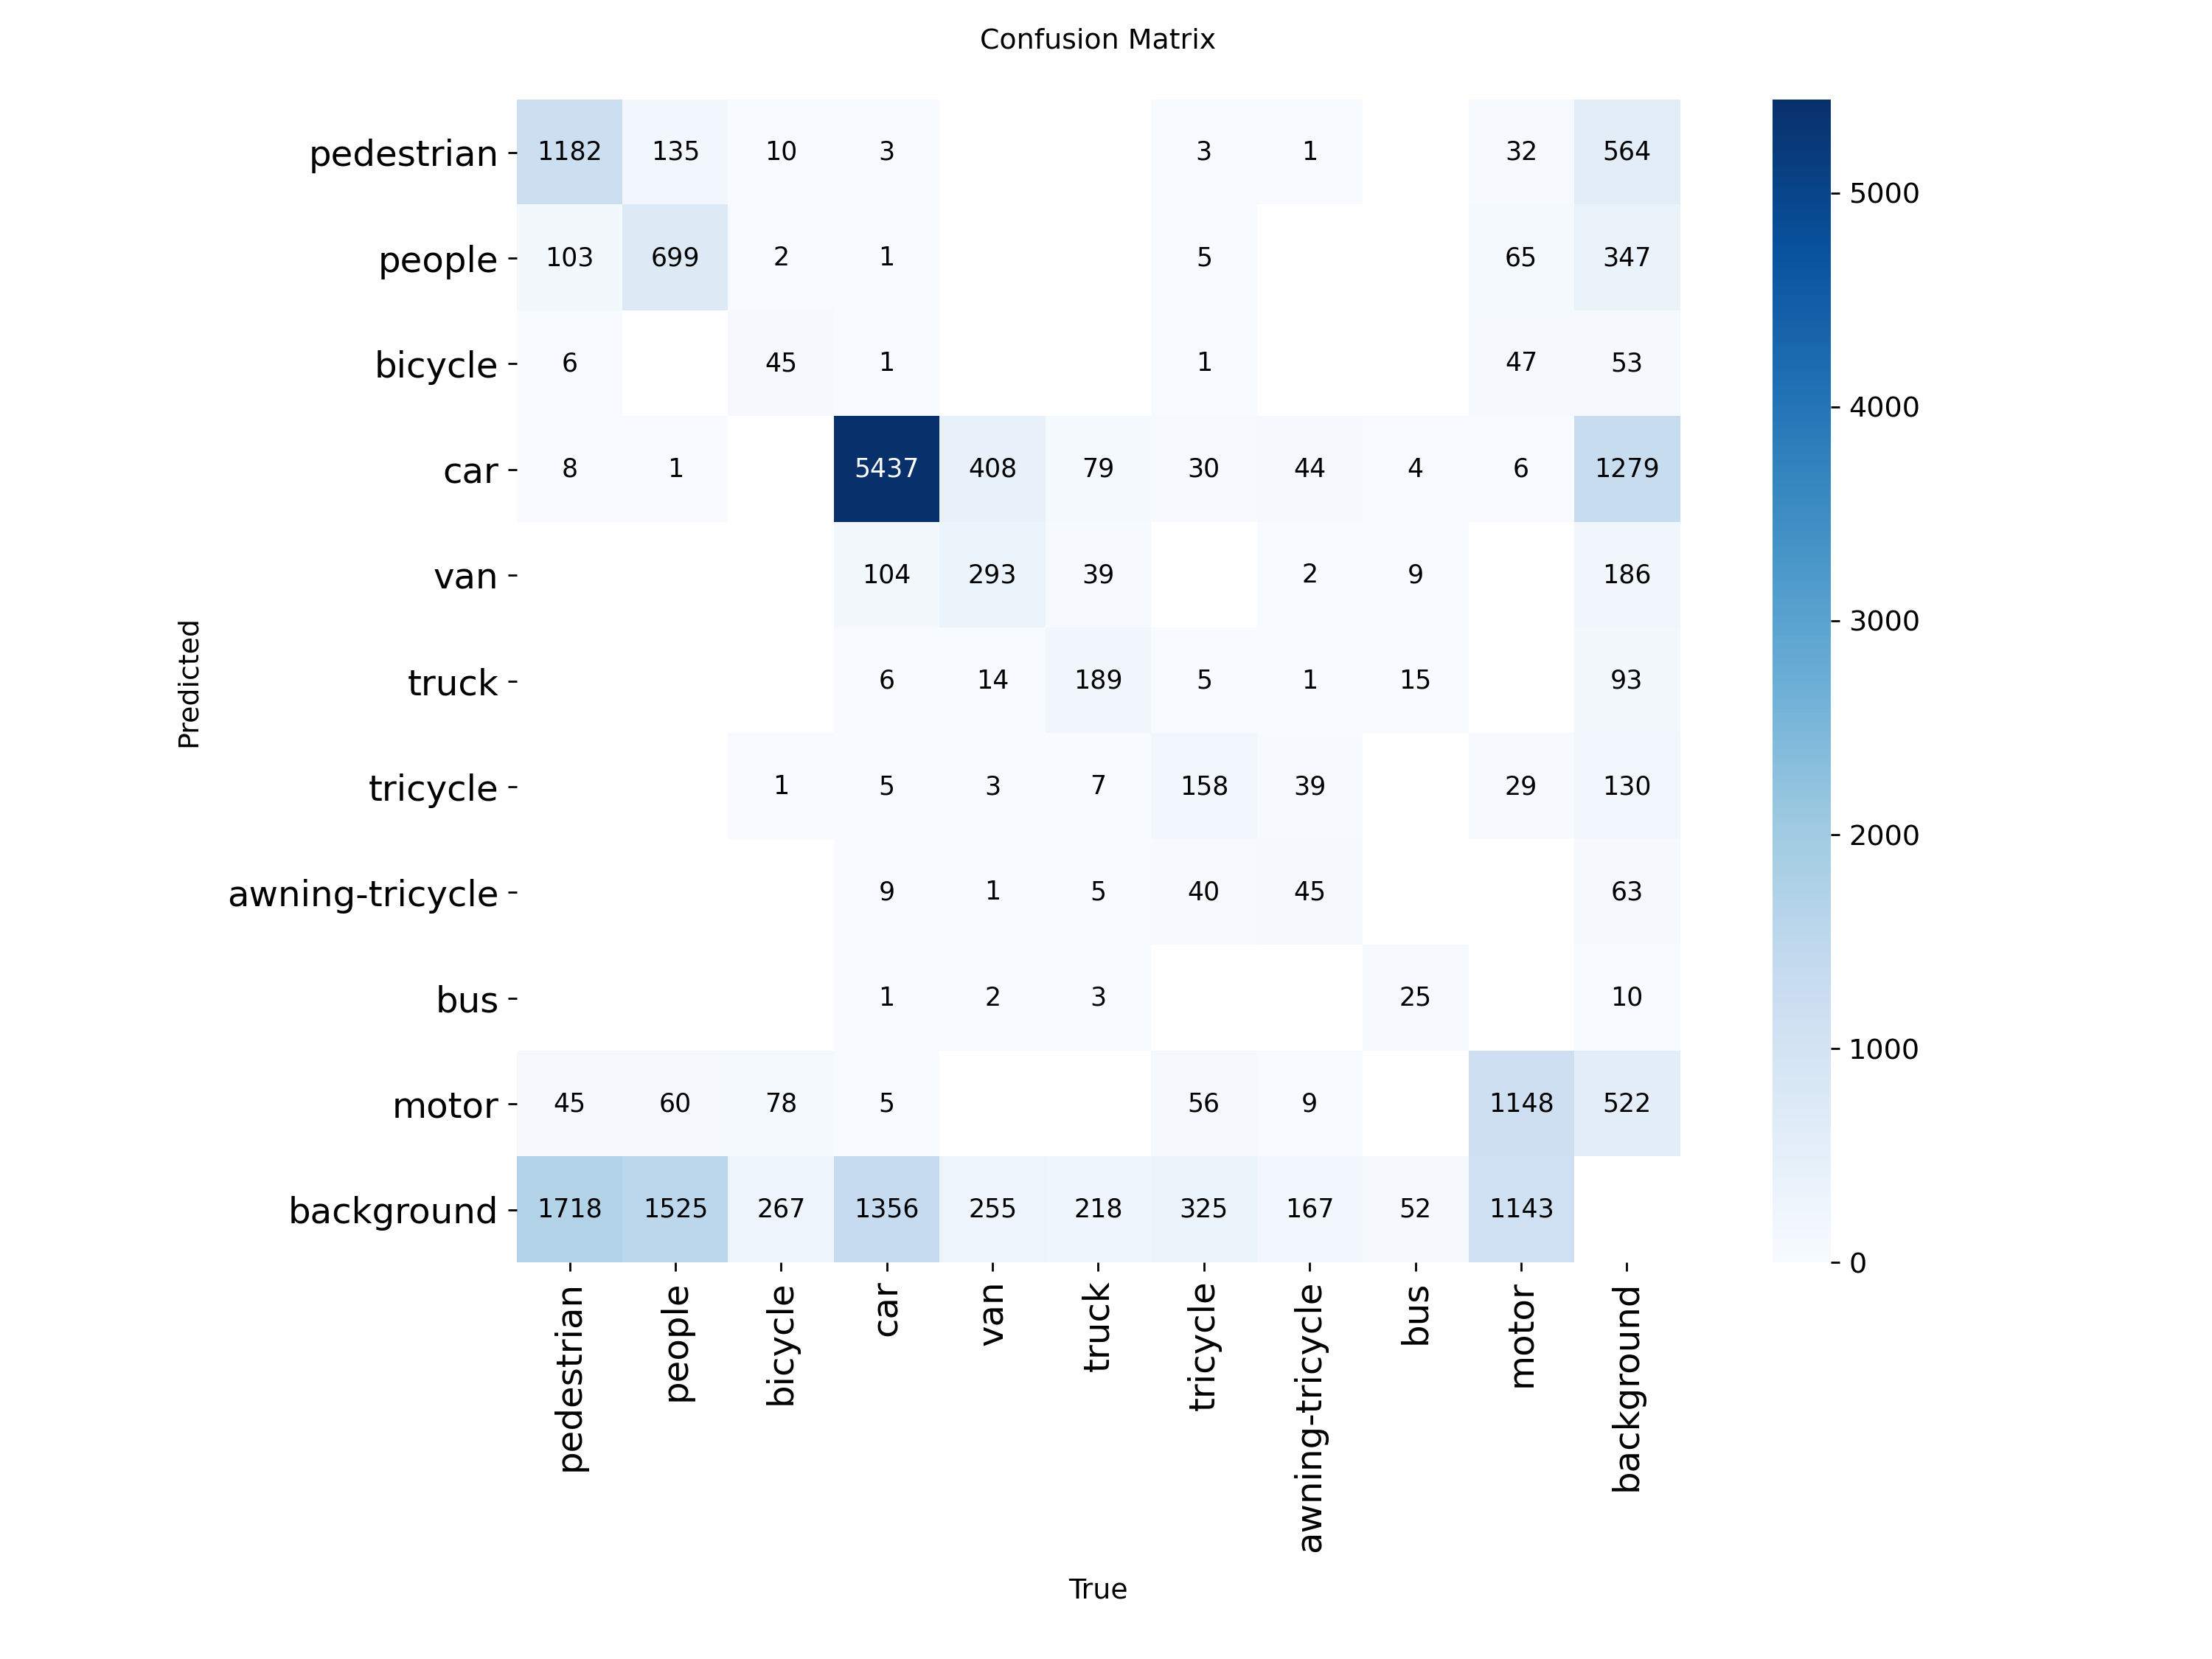

In [6]:
display(Image(f"{BASE}/confusion_matrix.png"))

### **Discussion**

### 4. Confusion Matrix

The confusion matrix shows detections across **all 10 classes**, consistent with the baseline run.
The overall detection pattern is similar to YOLOv11n but with noticeably better coverage across more classes, which reflects the increased capacity of the YOLOv11s model.

**Car:**
Car remains the strongest performing class, which is expected given it has the highest number of instances in the validation set.
The model detects cars confidently with relatively few misclassifications, contributing the most to the overall mAP.

**Pedestrian and People:**
Both pedestrian and people show improved detections compared to the baseline, though cross-class confusion between the two remains present.
This is expected since both classes describe human figures and are visually similar, especially at the small scales typical of drone imagery.
The rate of instances being suppressed as background has decreased compared to YOLOv11n, contributing to the improvement in recall from 0.3467 to 0.4014.

**Bicycle, Tricycle, and Awning-Tricycle:**
These classes still show the weakest detection performance among all classes.
They are small, infrequent objects that are harder to distinguish at low resolution.
While YOLOv11s shows some improvement over YOLOv11n for these classes, the gains are limited, suggesting that dataset size for these classes is a bigger bottleneck than model capacity alone.

**Bus and Van:**
Bus and van show improved detection performance compared to the baseline.
Van is still occasionally confused with car or truck due to visual similarity in shape and size, which is a common challenge in vehicle detection.

**Overall:**
The biggest issue shown in the confusion matrix is that the model still misses a lot of objects across most classes, incorrectly labeling them as background.
This is why recall (0.4014) is lower than precision (0.5294).
When the model does make a detection it tends to be correct, but it still fails to detect a large portion of the objects that are actually there.
That said, both precision and recall have improved compared to YOLOv11n (0.4472 and 0.3467 respectively), confirming that the larger model does help.

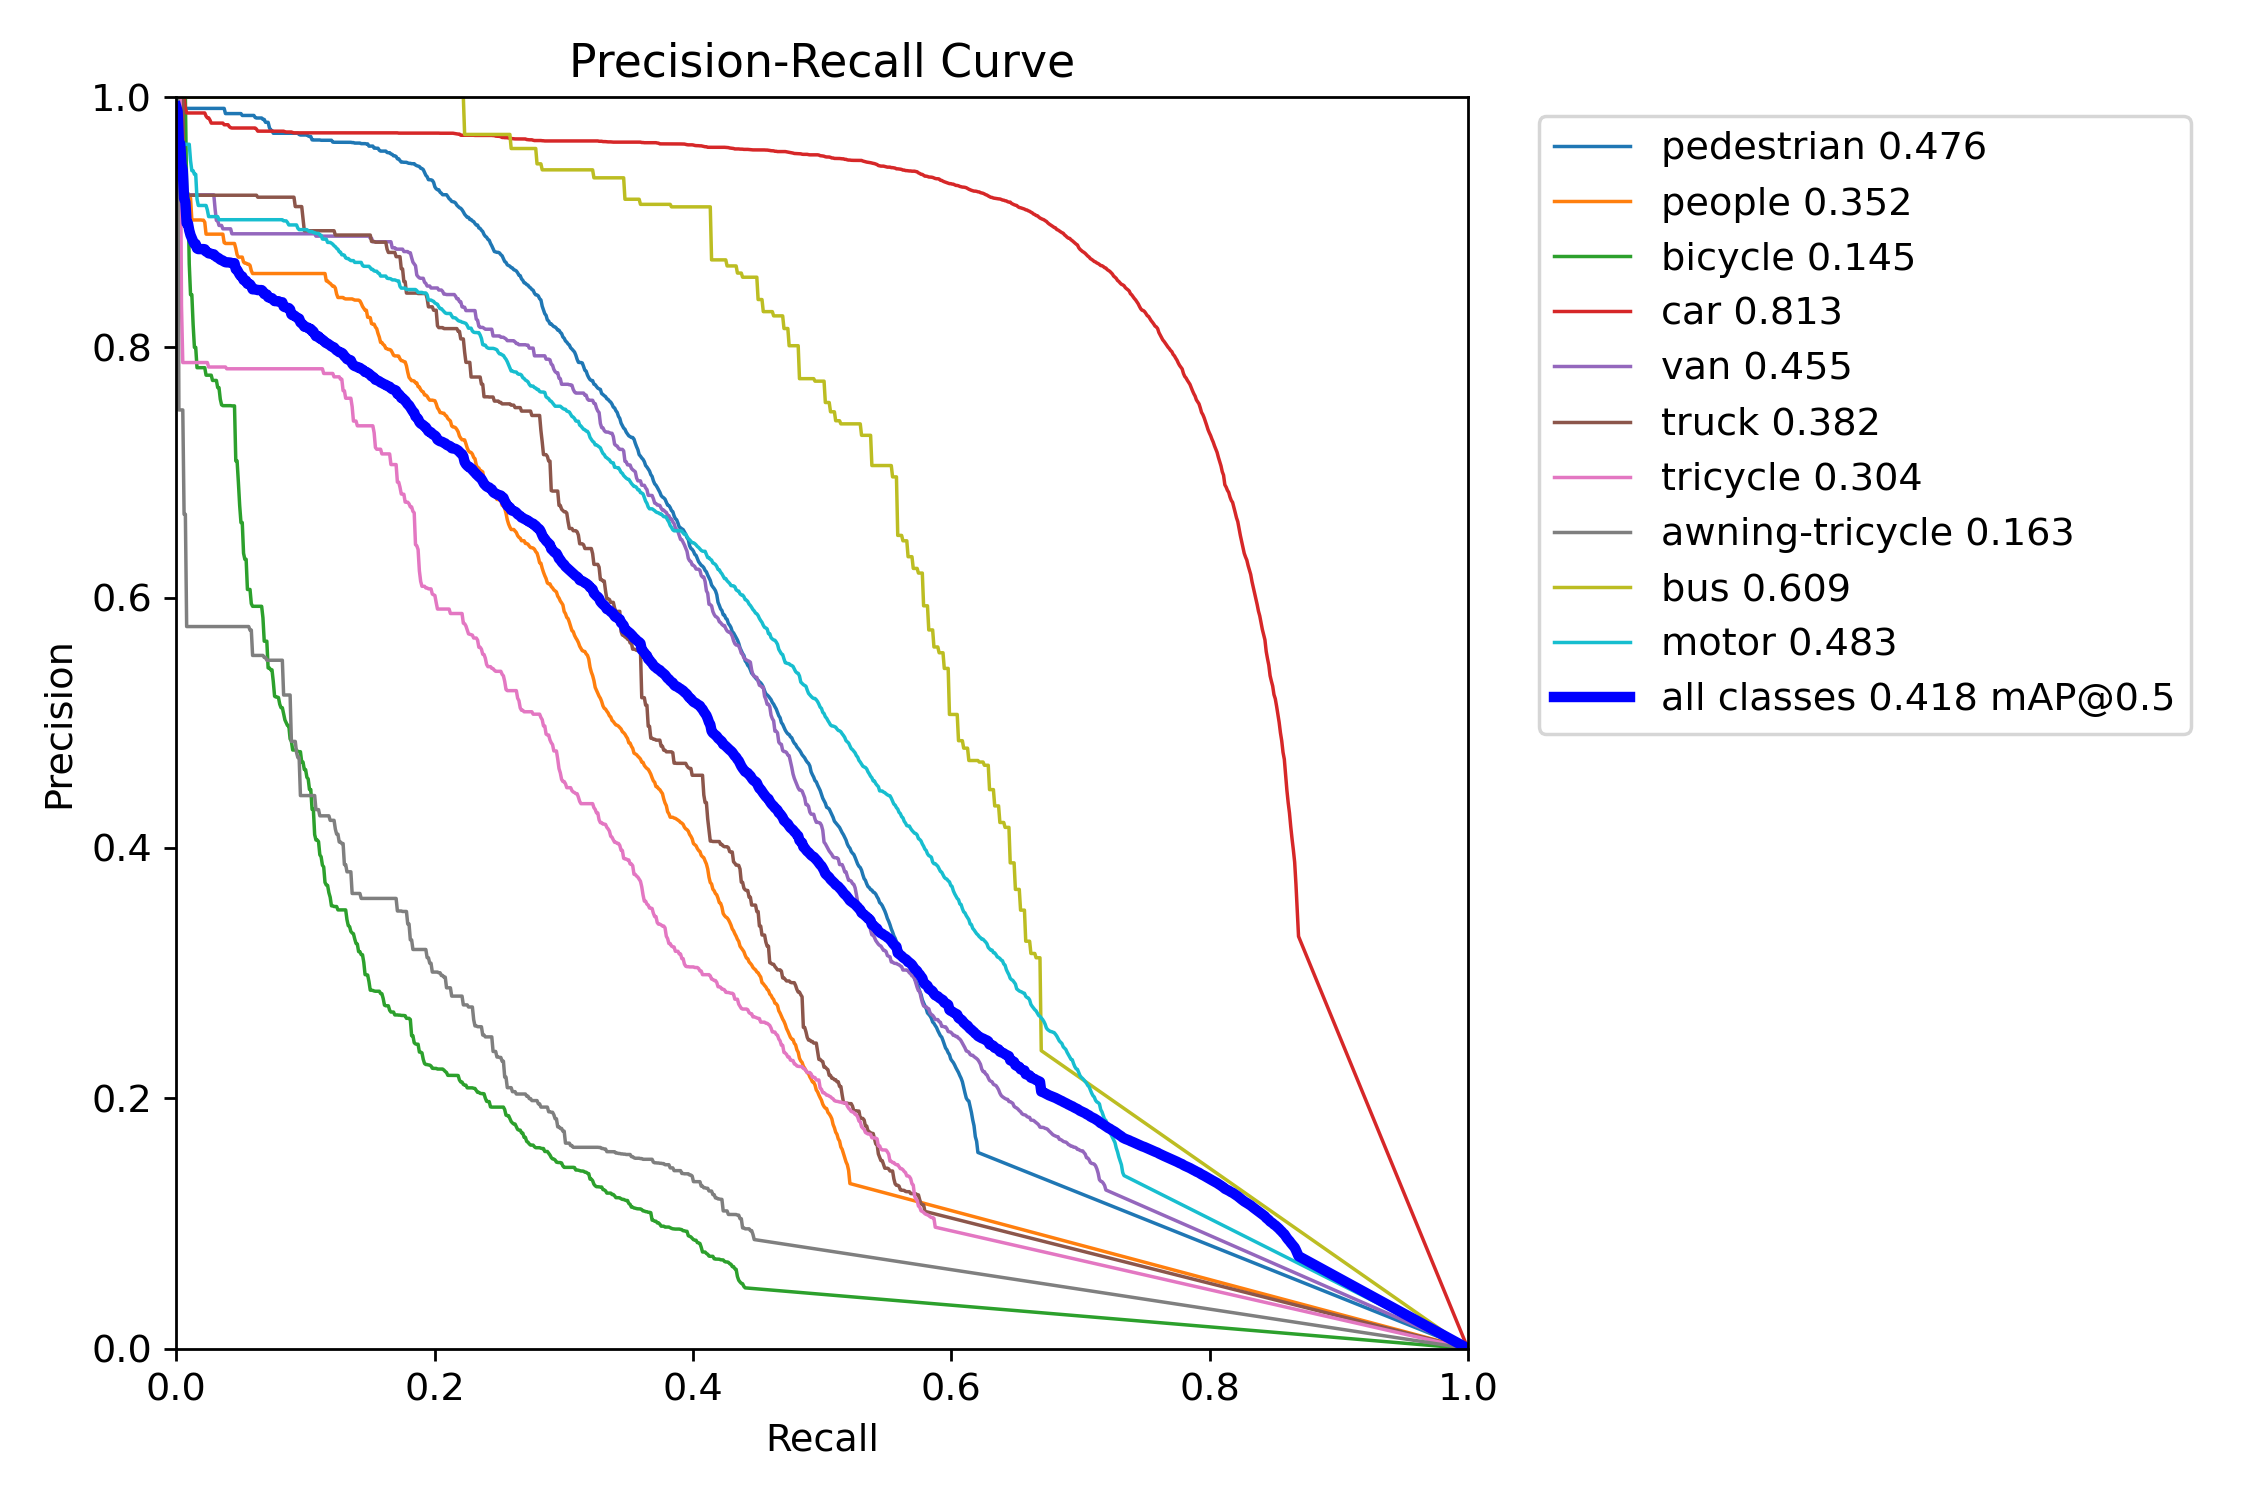

In [7]:
display(Image(f"{BASE}/BoxPR_curve.png"))

### 5. PR Curve (Precision Recall Curve)

The PR curve plots precision against recall at varying confidence thresholds for each class, with the area under each curve representing the per-class average precision.

**Car** has the strongest PR curve, maintaining high precision across a wide range of recall values.
This is consistent with car being the most represented class in the dataset and the model's strongest performer.

**Motor and Bus** show decent performance compared to the weaker classes, with precision staying fairly consistent at lower recall thresholds before starting to drop.
These classes appear often enough in the dataset that the model was able to pick up on their features reasonably well.

**Pedestrian and People** both show curves that start dropping in precision earlier than car and motor.
This is likely because pedestrian and people look very similar to each other, especially in drone footage where objects appear small.
As the model tries to detect more instances of each class, it starts confusing the two with each other, which causes precision to fall faster.

**Bicycle, Tricycle, and Awning-Tricycle** have the weakest curves, dropping steeply even at low recall values.
These are small, infrequent objects that the model struggles to detect reliably.
Even when the confidence threshold is lowered to try to catch more of these objects, the model ends up making a lot of wrong detections, meaning precision drops quickly.

The overall **mAP@50 of 0.4135** is the average across all 10 classes, which is an improvement over the YOLOv11n baseline (0.3494).
Model performance is still uneven across classes, improving detection for the smaller and less frequent objects would have the biggest impact on overall mAP.

### **Discussion Summary**

### 6. Overfitting Analysis

Overfitting has been **significantly reduced** compared to Part III. Evidence:
- The final training loss (1.2193) and validation loss (1.2578) are much closer together, with a gap of approximately **0.038**.
- In Part III, this gap was approximately 0.118, and the L2 regularization reduced it by roughly **68%**.
- The two curves track each other closely throughout training, which is the desired behavior indicating the model is generalizing rather than memorizing.

This confirms that increasing weight decay from 0.0005 to 0.001 was an effective intervention for reducing overfitting in YOLOv11s on the VisDrone dataset.

### 7. Underfitting Analysis

The model does **not exhibit underfitting**. The loss curves show clear, sustained descent and mAP (0.4122) is consistent with Part III (0.4135), showing the model did not lose meaningful detection capability as a result of the regularization.

This is an important finding: it shows that the weight decay value of 0.001 was well chosen.
Too high a weight decay would have caused underfitting by over-penalizing the model's parameters, but the results show this did not happen here.

### 8. Causes: Dataset Size and Model Capacity

**Dataset Size:**

The size of the training dataset plays a big role in how well the model can learn and generalize. When the dataset is small, the model has fewer examples to learn from, which increases the chance of overfitting because it may start memorizing the training images instead of learning general features. It also means the model gets less exposure to different object appearances, angles, and lighting conditions, which limits how well it can handle unseen images during validation.

Even with a good model, performance is ultimately limited by what the training data covers. If certain classes or scenarios are underrepresented, the model simply will not learn them well, as seen with the weaker classes in our confusion matrix.
L2 regularization helps with generalization but does not solve the underlying class imbalance problem.

While data augmentation techniques such as flipping, scaling, mosaic, and color jitter are applied by default in Ultralytics YOLO and do help the model see more variation, they are not a full replacement for having more real annotated images. Collecting and labeling more data, especially for the weaker classes, would likely lead to noticeable improvements in both recall and mAP.

**Model Capacity:**

YOLOv11s is the small variant of the YOLOv11 family, one step up from the nano model used in the baseline. It has more parameters and greater representational capacity, which allowed it to learn more complex detection features and achieve better results across all metrics compared to YOLOv11n.
However, the increased capacity also makes it more prone to overfitting when the dataset size stays the same.
The addition of L2 regularization in Part IV successfully addressed this by constraining the model's parameter values during training, resulting in a much smaller train/val gap without sacrificing detection performance.


In [8]:
summary = {
    "Model": ["YOLOv11n"],
    "Epochs": [len(df)],
    "mAP@50": [round(final['metrics/mAP50(B)'], 4)],
    "mAP@50-95": [round(final['metrics/mAP50-95(B)'], 4)],
    "Precision": [round(final['metrics/precision(B)'], 4)],
    "Recall": [round(final['metrics/recall(B)'], 4)],
}
pd.DataFrame(summary)

,Model,Epochs,mAP@50,mAP@50-95,Precision,Recall
0,YOLOv11n,168,0.4122,0.245,0.5304,0.3978


**Summary Table:**

| Observation | What Was Seen | Possible Reason |
|---|---|---|
| Reduced overfitting | Train/val gap dropped from ~0.118 (Part III) to ~0.038 (Part IV) | L2 regularization (weight decay=0.001) penalized large parameter values and improved generalization |
| Preserved mAP | mAP@50 of 0.4122 vs 0.4135 in Part III | Weight decay was not too aggressive, allowing the model to maintain detection performance |
| Model converged before epoch 200 | Early stopping triggered at epoch 168 | Learning rate scheduling slowed updates and the model had learned most of what the dataset could offer |
| Recall slightly lower (0.3978 vs 0.4014) | Marginally fewer true detections compared to Part III | The regularization slightly constrained the model's sensitivity, though the difference is very small |

---

### **Conclusion**

The Part IV improvement successfully addressed the overfitting identified in Part III. 
By increasing weight decay from 0.0005 to 0.001, the train/val loss gap was reduced by approximately 68% while maintaining nearly identical mAP performance. 
This demonstrates that L2 regularization is an effective and low-cost technique for improving generalization in YOLO models when training on a fixed dataset. 
The trade-off is a marginal reduction in recall (0.4014 to 0.3978), which is negligible in practice.

The main remaining bottleneck is dataset size and class imbalance, particularly for smaller object classes like bicycle, tricycle, and awning-tricycle. 
Addressing these would require more annotated training data rather than further architectural or regularization changes.